# Which one is a better plan?

You work as an analyst for the telecom operator Megaline. The company offers its clients two prepaid plans, Surf and Ultimate. The commercial department wants to know which of the plans brings in more revenue in order to adjust the advertising budget.

You are going to carry out a preliminary analysis of the plans based on a relatively small client selection. You'll have the data on 500 Megaline clients: who the clients are, where they're from, which plan they use, and the number of calls they made and text messages they sent in 2018. Your job is to analyze the clients' behavior and determine which prepaid plan brings in more revenue.

## Initialization

The goal of this analysis is to look at customer data to determine which plan generates more revenue for advertising purposes. First I will start by editing the data to get rid of errors and make it more readable. Then I will calculate statistical variables to later use in the analysis. Using the statistical variables I will test to see if the two plans have the same average revenue and if the average revenue for users in NY and NJ area differ from other regions.

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from math import factorial
import math as mt
from scipy import stats as st
import numpy as np

## Load data

In [2]:
calls = pd.read_csv('/datasets/megaline_calls.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')
users = pd.read_csv('/datasets/megaline_users.csv')

## Prepare the data

In [3]:
print(calls.head())

         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22


In [4]:
print(internet.sample(10))

             id  user_id session_date  mb_used
11099  1055_104     1055   2018-08-12   174.29
65401   1301_91     1301   2018-12-24     0.00
24217  1110_475     1110   2018-12-09   435.10
16855  1076_443     1076   2018-08-18   529.31
18269  1081_341     1081   2018-06-26     0.00
27858   1128_12     1128   2018-09-04   219.02
9124   1046_409     1046   2018-07-08    24.85
20904  1097_142     1097   2018-12-25   426.74
33115  1149_106     1149   2018-12-22     0.00
99111  1467_248     1467   2018-11-30     0.00


In [5]:
print(messages.head())

         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26


In [6]:
print(plans.head())

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


In [7]:
print(users.head())

   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

     reg_date      plan churn_date  
0  2018-12-24  ultimate        NaN  
1  2018-08-13      surf        NaN  
2  2018-10-21      surf        NaN  
3  2018-01-28      surf        NaN  
4  2018-05-23      surf        NaN  


## Plans

In [8]:
print(plans.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes
None


In [9]:
print(plans)

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


#### Analysis
The issues I see are that there are two different unit types for data used one is in megabytes where the other is in gigabytes this may cause problems later in the analysis if not changed. Also there seems to be incorrect data in the mb_per_month_included column those will also be changed to better reflect the two plans.

## Fix data

## Enrich data

## Users

In [10]:
print(users.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB
None


In [11]:
print(users.sample(5))

     user_id  first_name last_name  age  \
494     1494     Preston     Downs   70   
119     1119    Anderson    Palmer   60   
414     1414  Georgianne   Herring   30   
370     1370      Nenita   Vasquez   49   
177     1177     Seymour  Anderson   33   

                                          city    reg_date      plan  \
494  New York-Newark-Jersey City, NY-NJ-PA MSA  2018-04-19      surf   
119     Louisville/Jefferson County, KY-IN MSA  2018-10-05      surf   
414                     Urban Honolulu, HI MSA  2018-03-03      surf   
370     San Diego-Chula Vista-Carlsbad, CA MSA  2018-09-12  ultimate   
177            Seattle-Tacoma-Bellevue, WA MSA  2018-11-09      surf   

     churn_date  
494         NaN  
119         NaN  
414  2018-09-01  
370         NaN  
177         NaN  


#### Analysis
I see two main problems with this dataframe, one being that the reg_date column is an object when it should be displayed as datetime. Secondly in the churn_date column there are many nan values and only 34 actual dates, this column is also being displayed as a object and not a datetime datatype.

### Fix Data

In [12]:
users['reg_date'] = pd.to_datetime(users['reg_date'])

In [13]:
users['churn_date'] = pd.to_datetime(users['churn_date'], errors='coerce')

#### Analysis
Both columns churn_date and reg_date are converted to datetime64 datatypes to better examine the dates later in the analysis. In the churn_date column I used the parameter errors='coerce' to avoid errors for the nan values.

### Enrich Data

In [14]:
users['month'] = users['reg_date'].dt.month
print(users.info())
print(users.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
 8   month       500 non-null    int64         
dtypes: datetime64[ns](2), int64(3), object(4)
memory usage: 35.3+ KB
None
   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Hen

#### Analysis
I created a new column named month for later calculations.

## Calls

In [15]:
print(calls.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
None


In [16]:
print(calls.sample(5))

               id  user_id   call_date  duration
127207    1455_29     1455  2018-11-16      0.43
78212    1280_221     1280  2018-12-01      9.65
108043  1382_1094     1382  2018-09-05      9.57
100540   1359_422     1359  2018-11-24     13.59
53715    1193_113     1193  2018-10-01      4.76


#### Analysis
For the calls dataframe I can see two major issues, one being the call_date column is an object instead of a datetime datatype. Secondly the duration column is vague and a float value, changing it to an integer datatype will help with later calculations. 

### Fix data

In [17]:
calls['call_date'] = pd.to_datetime(calls['call_date'])

#### Analysis
Here I changed the call_date datatype to a datetime datatype.

### Enrich data

In [18]:
calls['duration_min'] = np.where(
    calls['duration'] == 0,
    0,
    np.ceil(calls['duration']))
calls['month'] = calls['call_date'].dt.month
print(calls.info())
print(calls.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            137735 non-null  object        
 1   user_id       137735 non-null  int64         
 2   call_date     137735 non-null  datetime64[ns]
 3   duration      137735 non-null  float64       
 4   duration_min  137735 non-null  float64       
 5   month         137735 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 6.3+ MB
None
         id  user_id  call_date  duration  duration_min  month
0   1000_93     1000 2018-12-27      8.52           9.0     12
1  1000_145     1000 2018-12-27     13.66          14.0     12
2  1000_247     1000 2018-12-27     14.48          15.0     12
3  1000_309     1000 2018-12-28      5.76           6.0     12
4  1000_380     1000 2018-12-30      4.22           5.0     12


#### Analysis
I created a new column named duration_min that changes the datatype of the duration column to a integer then added one to round the minutes up while keeping the 0 values the same. I also created a new column named month for later calculations.

## Messages

In [19]:
print(messages.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
None


In [20]:
print(messages.sample(5))

             id  user_id message_date
8445   1061_451     1061   2018-09-05
60303  1381_416     1381   2018-10-08
44094  1293_810     1293   2018-09-13
70273  1456_228     1456   2018-12-17
429     1004_99     1004   2018-07-31


#### Analysis
The only issues with this dataframe is the message_date column is an object datatype when it should be a datetime datatype. Also there needs to be a month column to make it easier for calculations later.

### Fix data

In [21]:
messages['message_date'] = pd.to_datetime(messages['message_date'])

#### Analysis
Here I changed the datatype for the message_date column to a datetime datatype.

### Enrich data

In [22]:
messages['month'] = messages['message_date'].dt.month
print(messages.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
 3   month         76051 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 2.3+ MB
None


#### Analysis
Here I created the new column month to make it simpler to calculate monthly usage later on.

## Internet

In [23]:
print(internet.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
None


In [24]:
print(internet.sample(5))

             id  user_id session_date  mb_used
96147   1449_68     1449   2018-12-26   669.90
19780   1090_11     1090   2018-12-13   413.90
52541  1236_409     1236   2018-10-14    52.36
23701  1109_279     1109   2018-08-01    82.21
59223   1267_25     1267   2018-12-02   131.87


#### Analysis
Here I can see there are two issues, one being the session_date column is an object when it should be a datetime datatype. Secondly the mb_used column is a float datatype, converting it to an integer datatype will make it easier to perform calculations later.

### Fix data

In [25]:
internet['session_date'] = pd.to_datetime(internet['session_date'])
print(internet.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB
None


#### Analysis
Here I changed the datatype for the session_date column to a datetime datatype and converted the mb_used column to integer datatype.

### Enrich data

In [26]:
internet['month'] = internet['session_date'].dt.month
print(internet.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
 4   month         104825 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 4.0+ MB
None


#### Analysis
I created a new column named gb_used that converts the megabytes to gigabytes by dividing it by 1000 then adding one to round up but does not perform the calculation on 0 values. I also created a new column named month for later calculations.

## Study plan conditions

In [27]:
print(plans)

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


## Aggregate data per user


In [28]:
user_calls = calls.groupby(['user_id', 'month']).size()
print(user_calls)

user_id  month
1000     12       16
1001     8        27
         9        49
         10       65
         11       64
                  ..
1498     12       39
1499     9        41
         10       53
         11       45
         12       65
Length: 2258, dtype: int64


#### Analysis
Here I grouped the calls dataframe by user_id and month counting the total values per month.

In [29]:
user_min = calls.groupby(['user_id', 'month'])['duration_min'].agg('sum')
print(user_min)

user_id  month
1000     12       124.0
1001     8        182.0
         9        315.0
         10       393.0
         11       426.0
                  ...  
1498     12       339.0
1499     9        346.0
         10       385.0
         11       308.0
         12       496.0
Name: duration_min, Length: 2258, dtype: float64


#### Analysis
Here I grouped the calls dataframe by the user_id and month, then calculated the sum of all the calls in the duration column per month.

In [30]:
user_messages = messages.groupby(['user_id', 'month']).size()
print(user_messages)

user_id  month
1000     12       11
1001     8        30
         9        44
         10       53
         11       36
                  ..
1496     9        21
         10       18
         11       13
         12       11
1497     12       50
Length: 1806, dtype: int64


#### Analysis
Here I grouped the messages dataframe by the user_id and month, then counted the total values per month.

In [31]:
internet_vol = internet.groupby(['user_id', 'month'])['mb_used'].agg('sum')
print(internet_vol)

user_id  month
1000     12        1901.47
1001     8         6919.15
         9        13314.82
         10       22330.49
         11       18504.30
                    ...   
1498     12       23137.69
1499     9        12984.76
         10       19492.43
         11       16813.83
         12       22059.21
Name: mb_used, Length: 2277, dtype: float64


#### Analysis
Here I grouped the internet dataframe by the user_id and month, then calculated the sum of mb_used per month.

In [32]:
user_data = pd.concat([user_calls, user_min, user_messages, internet_vol],
                      axis=1,
                      keys=['calls_count', 'minutes_used', 'message_count', 'mb_used'])\
    .reset_index()

print(user_data.head())

   user_id  month  calls_count  minutes_used  message_count   mb_used
0     1000     12         16.0         124.0           11.0   1901.47
1     1001      8         27.0         182.0           30.0   6919.15
2     1001      9         49.0         315.0           44.0  13314.82
3     1001     10         65.0         393.0           53.0  22330.49
4     1001     11         64.0         426.0           36.0  18504.30


#### Analysis
Here I combined the user_calls, user_min, user_messages, and internet_vol series to make a new dataframe called user_data and rename the columns for clarity.

In [33]:
users_data_plans = user_data.merge(
    users[['user_id', 'plan']], on='user_id', how='left')
final_data = users_data_plans.merge(
    plans, left_on='plan', right_on='plan_name', how='left')
print(final_data.head())

   user_id  month  calls_count  minutes_used  message_count   mb_used  \
0     1000     12         16.0         124.0           11.0   1901.47   
1     1001      8         27.0         182.0           30.0   6919.15   
2     1001      9         49.0         315.0           44.0  13314.82   
3     1001     10         65.0         393.0           53.0  22330.49   
4     1001     11         64.0         426.0           36.0  18504.30   

       plan  messages_included  mb_per_month_included  minutes_included  \
0  ultimate               1000                  30720              3000   
1      surf                 50                  15360               500   
2      surf                 50                  15360               500   
3      surf                 50                  15360               500   
4      surf                 50                  15360               500   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               70           7    

#### Analysis
Here I grouped the newly created user_data dataframe with the users dataframe columns user_id and plan to get the specific plan for each user and added the plan information to each user according to there plan.

In [34]:
final_data['minutes_used'] = final_data['minutes_used'].fillna(0)
final_data['message_count'] = final_data['message_count'].fillna(
    0).astype('int')

minutes_overage = np.where(final_data['minutes_used'] > final_data['minutes_included'],
                           final_data['minutes_used'] -
                           final_data['minutes_included'],
                           0
                           )
message_overage = np.where(final_data['message_count'] > final_data['messages_included'],
                           final_data['message_count'] -
                           final_data['messages_included'],
                           0
                           )

data_overage = np.where(final_data['mb_used'] > final_data['mb_per_month_included'],
                        final_data['mb_used'] -
                        final_data['mb_per_month_included'],
                        0
                        )
data_overage_gb = np.where(data_overage > 0,
                           np.ceil(data_overage / 1024),
                           0
                           )
minutes_cost = minutes_overage * final_data['usd_per_minute']
message_cost = message_overage * final_data['usd_per_message']
data_cost = data_overage_gb * final_data['usd_per_gb']

final_data['minutes_cost'] = minutes_cost
final_data['message_cost'] = message_cost
final_data['data_cost'] = data_cost
final_data['overage_cost'] = minutes_cost + message_cost + data_cost

final_data['monthly_revenue'] = final_data['usd_monthly_pay'] + \
    final_data['overage_cost']
print(final_data)

      user_id  month  calls_count  minutes_used  message_count   mb_used  \
0        1000     12         16.0         124.0             11   1901.47   
1        1001      8         27.0         182.0             30   6919.15   
2        1001      9         49.0         315.0             44  13314.82   
3        1001     10         65.0         393.0             53  22330.49   
4        1001     11         64.0         426.0             36  18504.30   
...       ...    ...          ...           ...            ...       ...   
2288     1498     12         39.0         339.0              0  23137.69   
2289     1499      9         41.0         346.0              0  12984.76   
2290     1499     10         53.0         385.0              0  19492.43   
2291     1499     11         45.0         308.0              0  16813.83   
2292     1499     12         65.0         496.0              0  22059.21   

          plan  messages_included  mb_per_month_included  minutes_included  \
0     ult

#### Analysis
Here I started by filling in the NAN values in the minutes_used and message_count columns with a 0 instead, I also converted data_overage to an integer and  rounded up 1 gigabyte same for minutes_used. Then I created filters using numpys where function to identify if the column is greater than the values included in the users plan, if so the users amount is subtracted from the amount aloud in the plan if not then it is zero. Following I multiplied the overage values by the cost per unit to find the cost of overage values. After I added the monthly cost for the users plan and the total overage cost for minutes, messages, and data to get the monthly revenue per user.

## Study user behaviour

### Calls

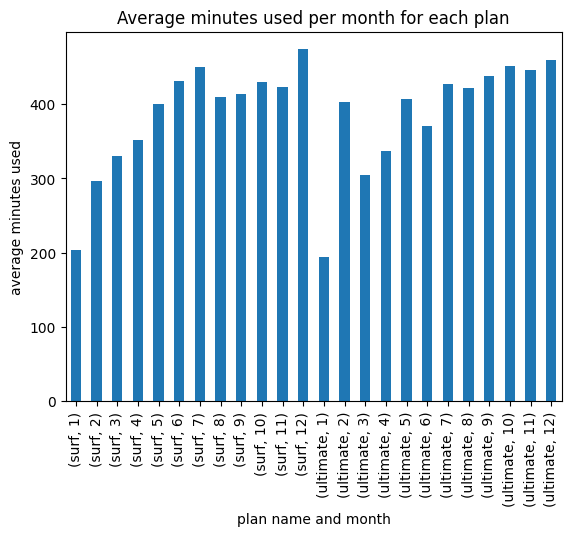

In [35]:
call_grp = final_data.groupby(['plan_name', 'month'])[
    'minutes_used'].agg('mean')
call_grp.plot(kind='bar', xlabel='plan name and month', ylabel='average minutes used',
              title='Average minutes used per month for each plan')
plt.show()

#### Analysis
Here i grouped the data by the plan name and the month then calculated the average minutes used for each plan per month. The chart shows the most used minutes on average occur in December for both plans, although the Surf plan in December has the most minutes used on average.

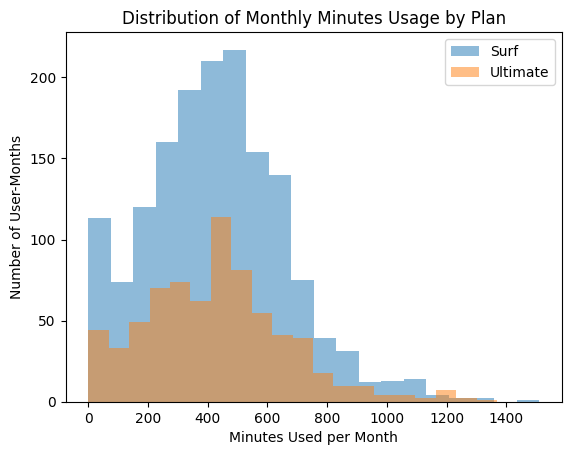

In [36]:
user_grp = final_data.groupby(['user_id', 'plan_name', 'month'])[
    'minutes_used'].agg('sum')
user_grp_df = user_grp.reset_index()
surf_data = user_grp_df[user_grp_df['plan_name'] == 'surf']['minutes_used']
ultimate_data = user_grp_df[user_grp_df['plan_name']
                            == 'ultimate']['minutes_used']

surf_data.plot(kind='hist', alpha=0.5, bins=20, label='Surf')
ultimate_data.plot(kind='hist', alpha=0.5, bins=20, label='Ultimate')
plt.xlabel('Minutes Used per Month')
plt.ylabel('Number of User-Months')
plt.title('Distribution of Monthly Minutes Usage by Plan')
plt.legend()
plt.show()

#### Analysis
The histogram shows most users use between 400 and 500 minutes per month with the Surf plan being more popular and has a higher frequency in the data.

In [37]:
call_stat = final_data.groupby(['plan_name', 'month'])[
    'minutes_used'].agg(['mean', 'var', 'std'])
print(call_stat)

                       mean           var         std
plan_name month                                      
surf      1      203.000000  15842.000000  125.865007
          2      297.000000  52226.500000  228.531179
          3      330.000000  35809.363636  189.233622
          4      351.540000  50866.743265  225.536567
          5      399.584416  59754.219754  244.446763
          6      431.298969  45592.628436  213.524304
          7      449.983471  61005.099725  246.992105
          8      410.111111  54344.645963  233.119381
          9      414.226804  46595.958656  215.860971
          10     429.729958  52278.664056  228.645280
          11     423.325088  51607.021602  227.171789
          12     473.836478  63629.518918  252.248923
ultimate  1      193.500000  16572.333333  128.733575
          2      403.142857  76889.476190  277.289517
          3      304.250000  61984.931818  248.967732
          4      336.857143  34888.928571  186.785783
          5      406.241379 

#### Analysis
Here the mean, variance, and standard deviation are calculated and grouped by the plan name and month.

<Figure size 1000x600 with 0 Axes>

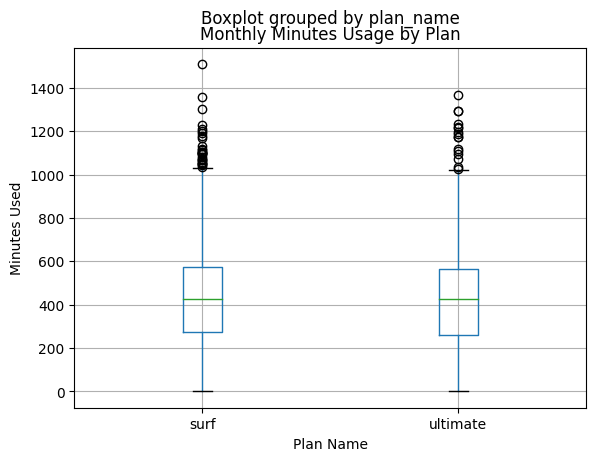

In [38]:
plt.figure(figsize=(10, 6))
final_data.boxplot(column='minutes_used', by='plan_name')
plt.title('Monthly Minutes Usage by Plan')
plt.xlabel('Plan Name')
plt.ylabel('Minutes Used')
plt.show()

#### Analysis
The boxplot shows the median is the same for both groups along with similar quartiles although the Surf plan has a higher outlier. Considering the charts both plans users typically behave the same in terms of calling.

### Messages

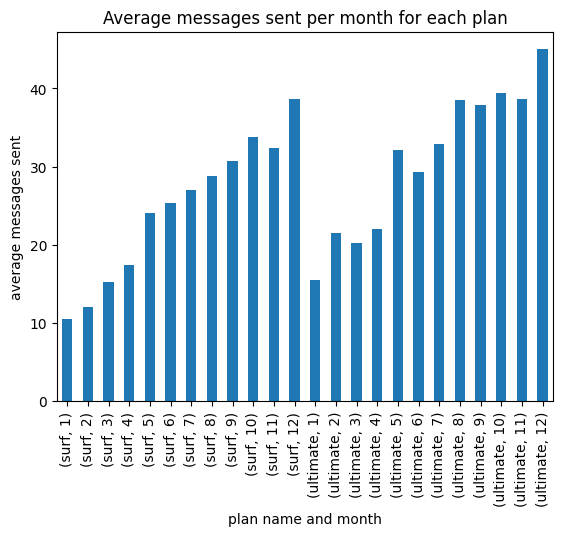

In [39]:
mess_grp = final_data.groupby(['plan_name', 'month'])[
    'message_count'].agg('mean')
mess_grp.plot(kind='bar', xlabel='plan name and month', ylabel='average messages sent',
              title='Average messages sent per month for each plan')
plt.show()

#### Analysis
Here the chart shows the average amount of messages sent by users per month for each plan, with the most messages being sent in December for both plans and the Ultimate plan being slightly higher on average.

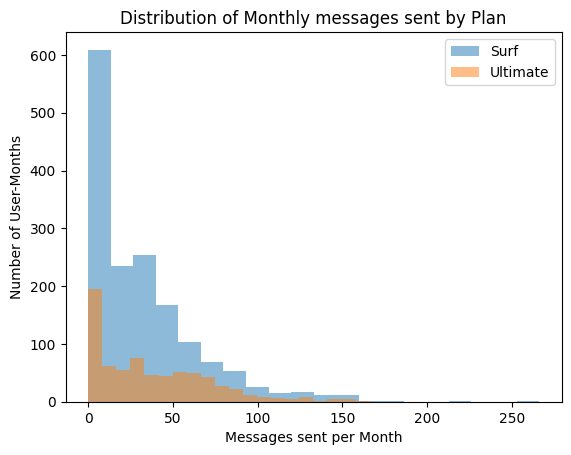

In [40]:
message_grp = final_data.groupby(['user_id', 'plan_name', 'month'])[
    'message_count'].agg('sum')
message_grp_df = message_grp.reset_index()
surf_data_message = message_grp_df[message_grp_df['plan_name']
                                   == 'surf']['message_count']
ultimate_data_message = message_grp_df[message_grp_df['plan_name']
                                       == 'ultimate']['message_count']

surf_data_message.plot(kind='hist', alpha=0.5, bins=20, label='Surf')
ultimate_data_message.plot(kind='hist', alpha=0.5, bins=20, label='Ultimate')
plt.xlabel('Messages sent per Month')
plt.ylabel('Number of User-Months')
plt.title('Distribution of Monthly messages sent by Plan')
plt.legend()
plt.show()

#### Analysis
The chart shows the amount of messages sent per month for most users is under 50 messages a month with the graph skewed right.

In [41]:
message_stat = final_data.groupby(['plan_name', 'month'])[
    'message_count'].agg(['mean', 'var', 'std'])
print(message_stat)

                      mean          var        std
plan_name month                                   
surf      1      10.500000   220.500000  14.849242
          2      12.000000   386.000000  19.646883
          3      15.260870   346.565217  18.616262
          4      17.400000   501.591837  22.396246
          5      24.012987   847.197198  29.106652
          6      25.298969   914.920103  30.247646
          7      27.033058   923.915565  30.395979
          8      28.777778  1029.515528  32.086064
          9      30.762887  1003.829496  31.683268
          10     33.839662  1275.465708  35.713663
          11     32.385159  1065.344034  32.639608
          12     38.600629  1458.158612  38.185843
ultimate  1      15.500000   313.666667  17.710637
          2      21.571429   478.285714  21.869744
          3      20.250000   654.386364  25.580977
          4      22.047619   544.147619  23.326972
          5      32.103448  1297.310345  36.018195
          6      29.340426   85

#### Analysis
Here I calculated the mean, variance, and standard deviation for the message_count column and grouped by the plan name and month. Showing the average messages sent for both plans remain below 50 with the standard deviation and mean being higher in the Ultimate plan.

<Figure size 1000x600 with 0 Axes>

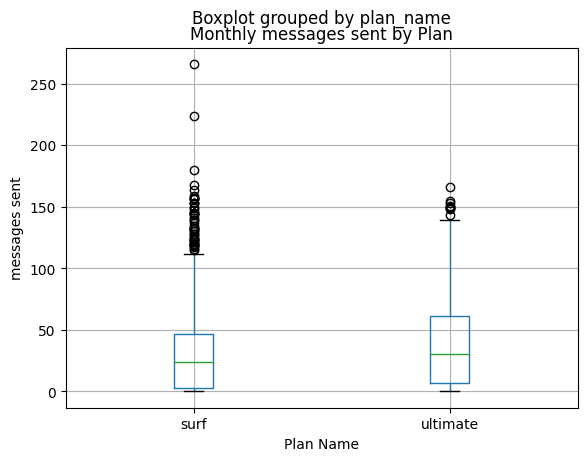

In [42]:
plt.figure(figsize=(10, 6))
final_data.boxplot(column='message_count', by='plan_name')
plt.title('Monthly messages sent by Plan')
plt.xlabel('Plan Name')
plt.ylabel('messages sent')
plt.show()

#### Analysis
Here the boxplot shows the Surf plan has a lower first and third quartiles along with a slightly lower median value. Also the Ultimate plan has higher values that are not considered outliers but the Surf plan has more frequent higher outliers for messages sent.

### Internet

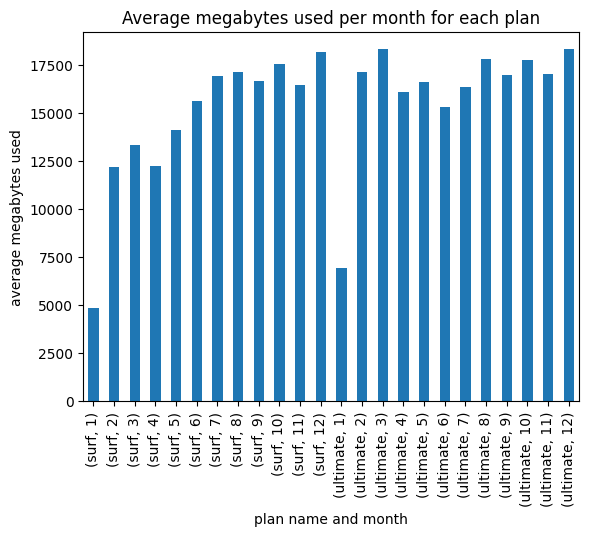

In [43]:
data_grp = final_data.groupby(['plan_name', 'month'])['mb_used'].agg('mean')
data_grp.plot(kind='bar', xlabel='plan name and month', ylabel='average megabytes used',
              title='Average megabytes used per month for each plan')
plt.show()

#### Analysis
The graph shows December has the most data used for both plans and the Ultimate plan typically uses slightly more data on average.

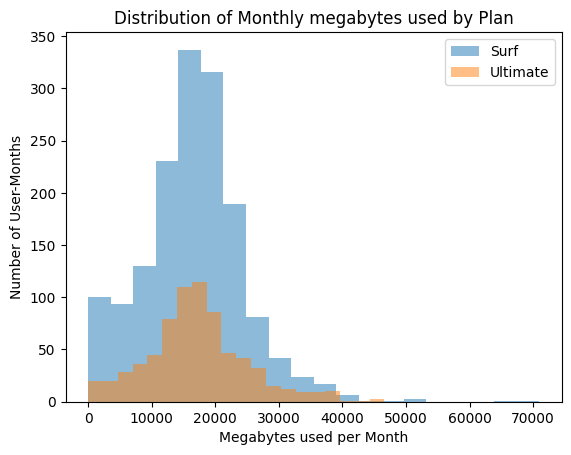

In [44]:
mb_grp = final_data.groupby(['user_id', 'plan_name', 'month'])[
    'mb_used'].agg('sum')
mb_grp_df = mb_grp.reset_index()
surf_data_mb = mb_grp_df[mb_grp_df['plan_name'] == 'surf']['mb_used']
ultimate_data_mb = mb_grp_df[mb_grp_df['plan_name'] == 'ultimate']['mb_used']

surf_data_mb.plot(kind='hist', alpha=0.5, bins=20, label='Surf')
ultimate_data_mb.plot(kind='hist', alpha=0.5, bins=20, label='Ultimate')
plt.xlabel('Megabytes used per Month')
plt.ylabel('Number of User-Months')
plt.title('Distribution of Monthly megabytes used by Plan')
plt.legend()
plt.show()

#### Analysis
The histogram shows most users use between 15000 and 20000 megabytes per month with the Surf plan being more popular and has a higher frequency in the data. The behavior of users within the two plans are typically the same regardless of their plan size, although the Ultimate plan has slightly higher data usage.

In [45]:
data_stat = final_data.groupby(['plan_name', 'month'])[
    'mb_used'].agg(['mean', 'var', 'std'])
print(data_stat)

                         mean           var           std
plan_name month                                          
surf      1       4874.860000  1.823995e+07   4270.825963
          2      12178.843333  4.367296e+07   6608.551952
          3      13345.440000  6.824556e+07   8261.086946
          4      12228.778571  5.722187e+07   7564.514094
          5      14119.728026  5.967252e+07   7724.799075
          6      15623.666632  4.509227e+07   6715.077831
          7      16923.463917  6.284327e+07   7927.374698
          8      17112.224403  7.059657e+07   8402.176549
          9      16677.397254  5.014277e+07   7081.155848
          10     17533.275256  5.942498e+07   7708.760082
          11     16455.548043  5.566336e+07   7460.787843
          12     18189.669590  7.133198e+07   8445.826008
ultimate  1       6918.092500  1.639471e+07   4049.038391
          2      17128.808571  3.764910e+07   6135.885948
          3      18321.518333  1.403392e+08  11846.483246
          4   

#### Analysis
Here I calculated the mean, variance, and standard deviation for the mb_used column and grouped by the plan name and month. Showing the average data used for both plans each month the average data used for the Ultimate plan is slightly higher than the Surf plan.

<Figure size 1000x600 with 0 Axes>

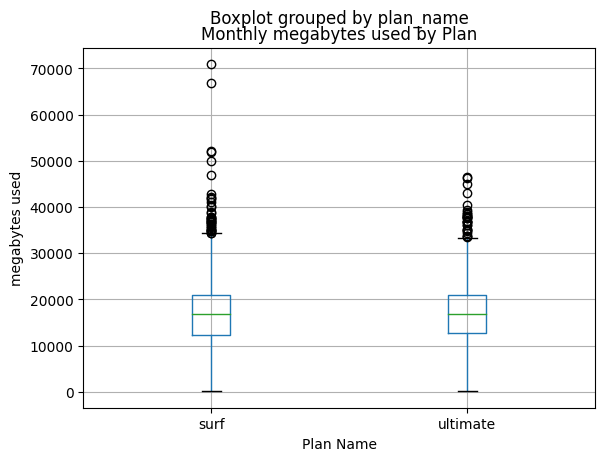

In [46]:
plt.figure(figsize=(10, 6))
final_data.boxplot(column='mb_used', by='plan_name')
plt.title('Monthly megabytes used by Plan')
plt.xlabel('Plan Name')
plt.ylabel('megabytes used')
plt.show()

#### Analysis
The boxplot shows the data for both plans internet traffic are relatively the same regardless of the data limit associated with the plan with the Surf plan having higher outliers.

## Revenue

[Likewise you have studied the user behaviour, statistically describe the revenue between the plans.]

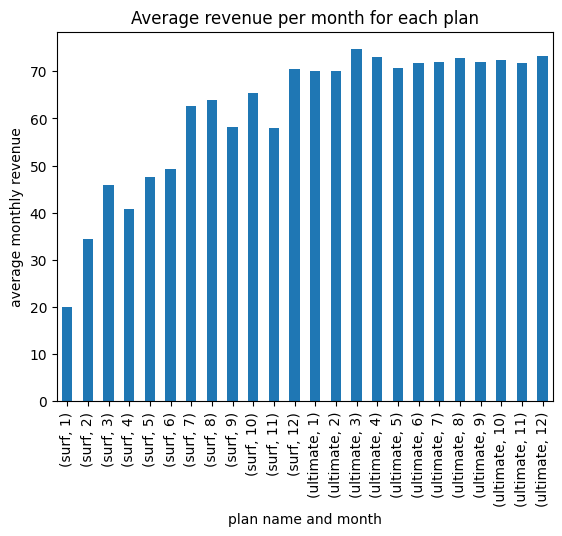

In [47]:
revenue_grp = final_data.groupby(['plan_name', 'month'])[
    'monthly_revenue'].agg('mean')
revenue_grp.plot(kind='bar', xlabel='plan name and month',
                 ylabel='average monthly revenue', title='Average revenue per month for each plan')
plt.show()

#### Analysis
Here the graph shows the average monthly revenue for both plans per month revealing the average revenue is greater for the Ultimate plan.

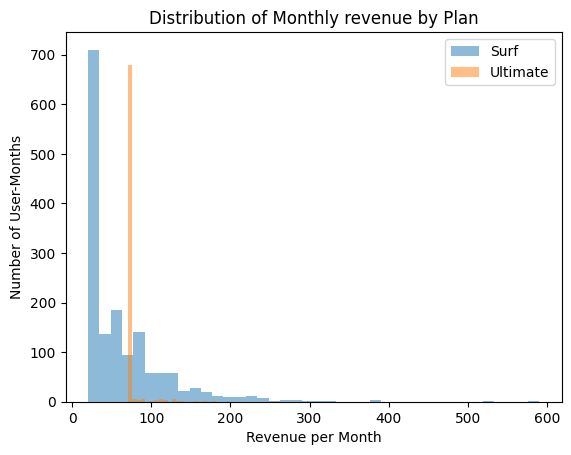

In [48]:
rev_grp = final_data.groupby(['user_id', 'plan_name', 'month'])[
    'monthly_revenue'].agg('sum')
rev_grp_df = rev_grp.reset_index()
surf_data_rev = rev_grp_df[rev_grp_df['plan_name']
                           == 'surf']['monthly_revenue']
ultimate_data_rev = rev_grp_df[rev_grp_df['plan_name']
                               == 'ultimate']['monthly_revenue']

surf_data_rev.plot(kind='hist', alpha=0.5, bins=40, label='Surf')
ultimate_data_rev.plot(kind='hist', alpha=0.5, bins=20, label='Ultimate')
plt.xlabel('Revenue per Month')
plt.ylabel('Number of User-Months')
plt.title('Distribution of Monthly revenue by Plan')
plt.legend()
plt.show()

#### Analysis
The histogram shows that most users with the Surf plan pay under 100 dollars per month and the Ultimate plan pays right around 70 to 100 dollars per month.

In [49]:
rev_stat = final_data.groupby(['plan_name', 'month'])[
    'monthly_revenue'].agg(['mean', 'var', 'std'])
print(rev_stat)

                      mean          var        std
plan_name month                                   
surf      1      20.000000     0.000000   0.000000
          2      34.396667   428.276100  20.694833
          3      45.941304  1512.023512  38.884747
          4      40.710600  1198.958402  34.625979
          5      47.628182  1967.540055  44.356962
          6      49.276289  1988.914046  44.597243
          7      62.674050  2943.388409  54.253004
          8      63.931173  3587.494901  59.895700
          9      58.271495  2260.644980  47.546240
          10     65.421224  3198.242612  56.553007
          11     58.004276  2494.182230  49.941788
          12     70.557044  4604.410868  67.855809
ultimate  1      70.000000     0.000000   0.000000
          2      70.000000     0.000000   0.000000
          3      74.666667   145.515152  12.062966
          4      73.000000   120.400000  10.972693
          5      70.724138    15.206897   3.899602
          6      71.638298    7

#### Analysis
Here I calculated the mean, variance, and standard deviation for the monthly_revenue column and grouped by the plan name and month. Showing the average revenue is higher for the Ultimate plan per month.

<Figure size 1000x600 with 0 Axes>

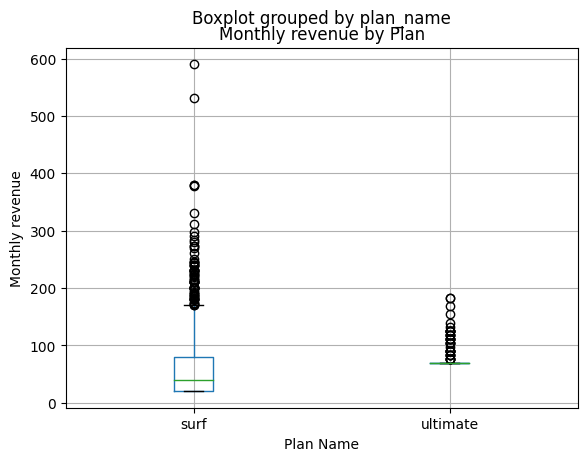

In [50]:
plt.figure(figsize=(10, 6))
final_data.boxplot(column='monthly_revenue', by='plan_name')
plt.title('Monthly revenue by Plan')
plt.xlabel('Plan Name')
plt.ylabel('Monthly revenue')
plt.show()

#### Analysis
The boxplot shows the data for average revenue for both plans differs significantly where the Surf plan has a wider distribution of revenue and the Ultimate plan has a higher overall median of revenue, meaning the base fee produces more revenue than overage charges.

## Test statistical hypotheses

In [51]:
surf_revenue = final_data[final_data['plan_name'] == 'surf']['monthly_revenue']
ultimate_revenue = final_data[final_data['plan_name']
                              == 'ultimate']['monthly_revenue']
alpha = .05
result = st.ttest_ind(surf_revenue, ultimate_revenue, equal_var=False)
print(result.pvalue)
if alpha > result.pvalue:
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis")

3.1703905481135734e-15
We reject the null hypothesis


#### Analysis
Since the p-value is less than the significance level of 0.05, we reject the null hypothesis. This indicates there is statistically significant evidence that the average monthly revenue of Surf users differs from the average monthly revenue of Ultimate users. To test the null hypothesis I filtered the final_data to compare both plans based on there average monthly_revenue to see if the average is equal to eachother for both plans.

In [52]:
final_data_city = final_data.merge(
    users[['user_id', 'city']], on='user_id', how='left')
ny_rev = final_data_city[final_data_city['city'] ==
                         'New York-Newark-Jersey City, NY-NJ-PA MSA']['monthly_revenue']
other_rev = final_data_city[final_data_city['city'] !=
                            'New York-Newark-Jersey City, NY-NJ-PA MSA']['monthly_revenue']
alpha = .05
results = st.ttest_ind(ny_rev, other_rev, equal_var=False)
print(results.pvalue)
if alpha > results.pvalue:
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis")

0.0335256158853001
We reject the null hypothesis


#### Analysis
Since the p-value is less than the significance level of 0.05, we reject the null hypothesis. This indicates there is statistically significant evidence that the average monthly revenue for users in the New York-Newark-Jersey City area differs from the average monthly revenue of users in other regions. To test the null hypothesis, I filtered the final_data into two groups users from the New York-Newark-Jersey City area and users from all other regions, then compared their average monthly_revenue.

#### Conclusion analysis
Based on the analysis of the 500 Megaline clients, the Ultimate plan brings in more revenue on average than the Surf plan. Although Surf users appear more often in the dataset and often generate overage charges, those extra charges are generally not enough to exceed the higher base monthly price of the Ultimate plan. Since Ultimate has a monthly fee of 70 dollars, compared to 20 dollars for Surf, it typically produces higher monthly revenue overall.

In terms of user behavior, both plan groups are relatively similar. Calling patterns were close across both plans, with similar medians and quartiles, and December showed the highest average minutes used. Messaging and internet usage followed a similar pattern, with both plans reaching their highest average usage in December as well. Ultimate users generally had slightly higher average message counts and data usage, but the overall behavior between the two plans was still fairly similar.

The revenue visualizations and summary statistics consistently showed that Ultimate users have a higher average monthly revenue. The boxplot also showed that Surf had a wider spread in revenue, which supports the idea that Surf users are more likely to incur overage charges, but not at a level high enough to outperform Ultimate in total revenue. The first hypothesis test showed there is statistically significant evidence that the average monthly revenue of Surf users differs from the average monthly revenue of Ultimate users.

The second hypothesis test also showed a statistically significant difference in average monthly revenue between users in the New York-Newark-Jersey City area and users in other regions. To test this, the data was divided into two groups users from the New York-Newark-Jersey City area and users from all other regions, and their average monthly revenue was compared. This suggests that region may also play a role in revenue differences in this sample.

Overall, the analysis shows that the Ultimate plan is the stronger revenue-generating plan for Megaline. Based on these results, Megaline should consider focusing more of its advertising budget on promoting the Ultimate plan.